# Notebook Structure
1. Import Libraries
2. Load Engineered Dataset
3. Prepare Data
4. Train Random Forest Model
5. Cross Validation
6. Feature Importance
7. Permutation Importance
8. Prediction Reliability
9. Business Insights
10. Save Final Model

In [1]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import joblib

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("../output/insurance_with_bmi.csv")

In [3]:
# Prepare Data
X = df.drop("PremiumPrice", axis=1)
y = df["PremiumPrice"]

In [6]:
# Split the dataset into features and target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='r2')

print("Cross-Validation R² Scores:", cv_scores)
print("Mean R² Score:", np.mean(cv_scores))
print("Standard Deviation of R² Scores:", np.std(cv_scores))

Cross-Validation R² Scores: [0.59324911 0.88615288 0.80083056 0.70299787 0.68921214]
Mean R² Score: 0.7344885081114017
Standard Deviation of R² Scores: 0.10039275569340597


## Key findings:

The Random Forest model achieved an R² score of 0.8931 on the test dataset. Five-fold cross-validation produced an average R² score of 0.7345 (standard deviation 0.1004), indicating generally good predictive performance with moderate variation across different data splits. 

This suggests that the model generalizes reasonably well while highlighting the importance of validating performance on multiple subsets of the data.

In [22]:
# Save Cross Validation Results
cv_df = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "R2_Score": cv_scores
})

cv_df

,Fold,R2_Score
0,1,0.593249
1,2,0.886153
2,3,0.800831
3,4,0.702998
4,5,0.689212


In [23]:
cv_df.to_csv(
    "../output/cross_validation_results.csv",
    index=False
)

print("Cross Validation CSV saved.")

Cross Validation CSV saved.


In [7]:
# Feature Importance of Random Forest 
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Age,0.618922
3,AnyTransplants,0.095502
6,Weight,0.085925
10,BMI,0.054768
4,AnyChronicDiseases,0.037926
9,NumberOfMajorSurgeries,0.035694
5,Height,0.030771
8,HistoryOfCancerInFamily,0.022666
2,BloodPressureProblems,0.009113
1,Diabetes,0.005543


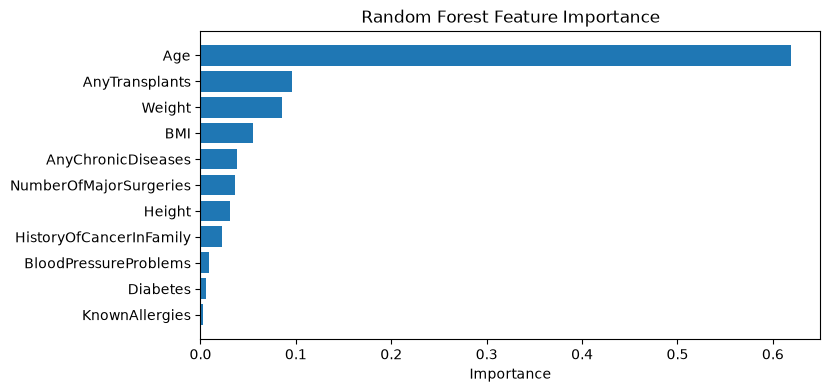

In [9]:
# Plot the importance
plt.figure(figsize=(8,4))
plt.barh(importance["Feature"], importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [20]:
# Save Feature Importance
importance.to_csv(
    "../output/feature_importance.csv",
    index=False
)

print("Feature Importance CSV saved.")

Feature Importance CSV saved.


In [10]:
# Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42)

perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df

,Feature,Importance
0,Age,1.138644
3,AnyTransplants,0.217992
6,Weight,0.121293
4,AnyChronicDiseases,0.089212
8,HistoryOfCancerInFamily,0.050543
9,NumberOfMajorSurgeries,0.028485
10,BMI,0.026840
2,BloodPressureProblems,0.025877
5,Height,0.000637
1,Diabetes,0.000231


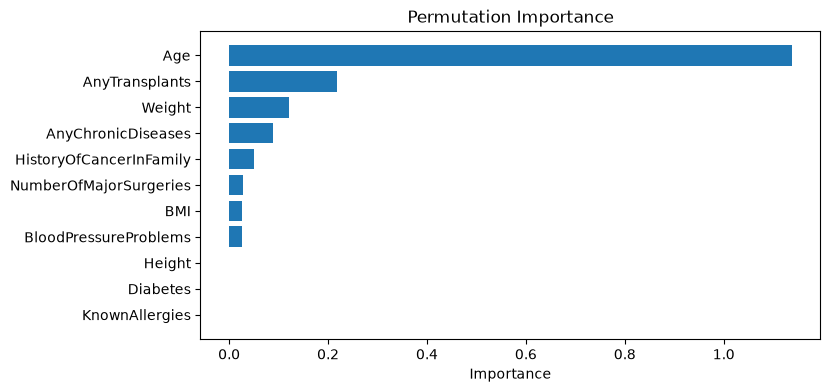

In [16]:
plt.figure(figsize=(8,4))

plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)

plt.title("Permutation Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [21]:
# Save Permutation Importance
perm_df.to_csv(
    "../output/permutation_importance.csv",
    index=False
)

print("Permutation Importance CSV saved.")

Permutation Importance CSV saved.


In [12]:
# Prediction Reliability
predictions = rf.predict(X_test)
residuals = y_test - predictions
residual_std = residuals.std()
print("Residual Standard Deviation:", residual_std)

Residual Standard Deviation: 2140.549447726765


In [13]:
# Approximate 95% prediction interval
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

results["Lower_95"] = (
    results["Predicted"] - 1.96 * residual_std
)

results["Upper_95"] = (
    results["Predicted"] + 1.96 * residual_std
)

results.head()

,Actual,Predicted,Lower_95,Upper_95
0,31000,29750.0,25554.523082,33945.476918
1,31000,30150.0,25954.523082,34345.476918
2,29000,30230.0,26034.523082,34425.476918
3,15000,16570.0,12374.523082,20765.476918
4,23000,23100.0,18904.523082,27295.476918


# Business Insights

## Key Findings

### 1. Age is the Primary Driver of Insurance Premiums

Both Random Forest Feature Importance (0.6189) and Permutation Importance (1.1386) identified **Age** as the most influential factor affecting insurance premium prices.

**Business Insight:**
- Older individuals generally present a higher health risk and are therefore associated with higher insurance premiums.
- Age should remain one of the primary variables used in premium calculation and customer risk assessment.

### 2. History of Organ Transplants Significantly Increases Premiums

**AnyTransplants** was the second most important predictor in both feature importance methods.

**Business Insight:**
- Customers with a history of organ transplants are likely to require ongoing medical care and monitoring.
- Insurance companies should classify these customers as higher-risk policyholders and adjust premium pricing accordingly.

### 3. Body Weight Contributes More Than BMI

The model assigned greater importance to **Weight** than **BMI**.

- Weight Importance: **0.0859**
- BMI Importance: **0.0548**

**Business Insight:**
- Although BMI is a clinically meaningful feature, body weight alone provides stronger predictive power for this dataset.
- Both variables can be retained for modeling, but Weight contributes more to premium prediction.

### 4. Chronic Diseases Increase Insurance Risk

**AnyChronicDiseases** is among the important predictors of insurance premiums.

**Business Insight:**
- Customers with chronic illnesses generally require more frequent medical care.
- These customers are expected to generate higher healthcare costs, resulting in higher insurance premiums.

### 5. Previous Medical History Influences Premiums

Variables such as **HistoryOfCancerInFamily** and **NumberOfMajorSurgeries** contributed to premium prediction, although their influence was lower than Age and Transplant history.

**Business Insight:**
- Family medical history and previous surgeries provide additional information about long-term health risk.
- These variables should be incorporated into insurance risk assessment rather than used in isolation.

### 6. Diabetes and Blood Pressure Have Lower Predictive Importance

Although hypothesis testing showed statistically significant differences for **Diabetes** and **BloodPressureProblems**, their feature importance values in the Random Forest model were relatively low.

**Business Insight:**
- These conditions are associated with premium differences, but they contribute less to prediction when considered alongside stronger factors such as Age and Transplant history.
- This demonstrates that statistical significance does not necessarily imply high predictive importance.

### 7. Known Allergies Have Minimal Impact

**KnownAllergies** showed almost zero importance in both Random Forest and Permutation Importance analyses.

**Business Insight:**
- Known allergies have minimal influence on premium prediction in this dataset.
- This variable contributes little to model performance and could be considered for removal in future model optimization after additional validation.

## Overall Business Conclusion

The Random Forest model identified **Age, AnyTransplants, Weight, BMI, AnyChronicDiseases, and NumberOfMajorSurgeries** as the most influential factors affecting insurance premium prices.

These insights can help insurance companies:

- Improve premium pricing strategies.
- Develop more accurate customer risk profiles.
- Design personalized insurance plans based on individual health characteristics.
- Enhance underwriting decisions using data-driven risk assessment.
- Support fair and transparent premium calculation policies.

Overall, the model demonstrates that combining demographic information with medical history provides accurate and reliable predictions of insurance premium prices.

In [18]:
# Save the model
joblib.dump(
    rf,
    "../models/random_forest_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
